In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# download the data from kaggle
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("philiphyde1/nfl-stats-1999-2022")

100%|██████████| 48.2M/48.2M [00:00<00:00, 170MB/s]

Extracting files...


In [3]:
print("Files in the dataset folder:", os.listdir(dataset_path))

Files in the dataset folder: ['yearly_team_stats_defense.csv', 'weekly_player_stats_offense.csv', 'weekly_player_stats_defense.csv', 'yearly_player_stats_offense.csv', 'yearly_team_stats_offense.csv', 'weekly_team_stats_offense.csv', 'weekly_team_stats_defense.csv', 'yearly_player_stats_defense.csv']


In [9]:
# Load the CSV file into a DataFrame
# [weekly_player_stats_defense.csv'', 'weekly_player_stats_defense.csv', 'weekly_team_stats_defense.csv', 'weekly_team_stats_defense.csv', 'yearly_player_stats_defense.csv', 'yearly_player_stats_defense.csv', 'yearly_team_stats_defense.csv', 'yearly_team_stats_defense.csv']
weekly_df_defense = pd.read_csv(os.path.join(dataset_path, 'weekly_team_stats_defense.csv'))

weekly_df_offense = pd.read_csv(os.path.join(dataset_path, 'weekly_team_stats_offense.csv'))

In [5]:
weekly_df_defense.head()

,game_id,season,week,team,season_type,safety,interception,fumble,fumble_lost,fumble_forced,...,average_solo_tackle,average_assist_tackle,average_tackle_with_assist,average_sack,average_qb_hit,average_def_touchdown,average_defensive_two_point_attempt,average_defensive_two_point_conv,average_defensive_extra_point_attempt,average_defensive_extra_point_conv
0,2012_01_SEA_ARI,2012,1,ARI,REG,0,1,2,1,1,...,55.000000,6.0,4.000000,3.0,8.000000,0.000000,0.0,0.0,0,0
1,2012_02_ARI_NE,2012,2,ARI,REG,0,1,0,0,0,...,51.000000,7.0,2.000000,3.5,7.000000,0.000000,0.0,0.0,0,0
2,2012_03_PHI_ARI,2012,3,ARI,REG,0,0,2,2,2,...,49.333333,6.0,1.666667,4.0,9.333333,0.333333,0.0,0.0,0,0
3,2012_04_MIA_ARI,2012,4,ARI,REG,0,2,4,2,3,...,50.500000,6.5,2.500000,4.0,9.500000,0.250000,0.0,0.0,0,0
4,2012_05_ARI_STL,2012,5,ARI,REG,0,1,0,0,0,...,47.400000,6.2,2.000000,3.4,8.800000,0.200000,0.0,0.0,0,0


In [10]:
num_columns_df = weekly_df_defense.shape[1]
num_rows_df = weekly_df_defense.shape[0]
column_names_df = weekly_df_defense.columns.tolist()

print(f"The dataset has {num_columns_df} columns and {num_rows_df} rows")

for col in column_names_df:
    null_count = weekly_df_defense[col].isnull().sum()  # Count null values
    print(f"Column: {col}, "
          f"Type: {weekly_df_defense[col].dtype}, "
          f"Unique Values: {weekly_df_defense[col].nunique()}, "
          f"Null Values: {null_count} ({null_count/num_rows_df:.1%})")

The dataset has 65 columns and 7088 rows
Column: game_id, Type: object, Unique Values: 3544, Null Values: 0 (0.0%)
Column: season, Type: int64, Unique Values: 13, Null Values: 0 (0.0%)
Column: week, Type: int64, Unique Values: 22, Null Values: 0 (0.0%)
Column: team, Type: object, Unique Values: 32, Null Values: 0 (0.0%)
Column: season_type, Type: object, Unique Values: 2, Null Values: 0 (0.0%)
Column: safety, Type: int64, Unique Values: 3, Null Values: 0 (0.0%)
Column: interception, Type: int64, Unique Values: 7, Null Values: 0 (0.0%)
Column: fumble, Type: int64, Unique Values: 8, Null Values: 0 (0.0%)
Column: fumble_lost, Type: int64, Unique Values: 6, Null Values: 0 (0.0%)
Column: fumble_forced, Type: int64, Unique Values: 7, Null Values: 0 (0.0%)
Column: fumble_not_forced, Type: int64, Unique Values: 6, Null Values: 0 (0.0%)
Column: fumble_out_of_bounds, Type: int64, Unique Values: 5, Null Values: 0 (0.0%)
Column: solo_tackle, Type: int64, Unique Values: 56, Null Values: 0 (0.0%)
Co

In [112]:
weekly_df_defense['total_tackles_and_assists'] = (weekly_df_defense['solo_tackle'] + weekly_df_defense['assist_tackle'] + weekly_df_defense['tackle_with_assist'] + weekly_df_defense['sack'])


weekly_df_defense[weekly_df_defense['season'].isin([2024])].head()

,game_id,season,week,team,season_type,safety,interception,fumble,fumble_lost,fumble_forced,...,average_tackle_with_assist,average_sack,average_qb_hit,average_def_touchdown,average_defensive_two_point_attempt,average_defensive_two_point_conv,average_defensive_extra_point_attempt,average_defensive_extra_point_conv,total_tackles_and_assists,home_away_status
6518,2024_01_ARI_BUF,2024,1,ARI,REG,0,0,1,1,1,...,14.000000,2.00,3.000000,0.0,0.0,0.0,0,0,66,Away
6519,2024_02_LA_ARI,2024,2,ARI,REG,0,0,1,1,1,...,10.000000,3.50,6.000000,0.0,0.0,0.0,0,0,56,Home
6520,2024_03_DET_ARI,2024,3,ARI,REG,0,1,0,0,0,...,9.333333,3.00,4.666667,0.0,0.0,0.0,0,0,68,Home
6521,2024_04_WAS_ARI,2024,4,ARI,REG,0,1,0,0,0,...,8.250000,2.25,3.750000,0.0,0.0,0.0,0,0,63,Home
6522,2024_05_ARI_SF,2024,5,ARI,REG,0,2,1,1,1,...,7.200000,2.20,4.000000,0.0,0.0,0.0,0,0,54,Away


<Axes: xlabel='total_tackles_and_assists', ylabel='fumble_lost'>

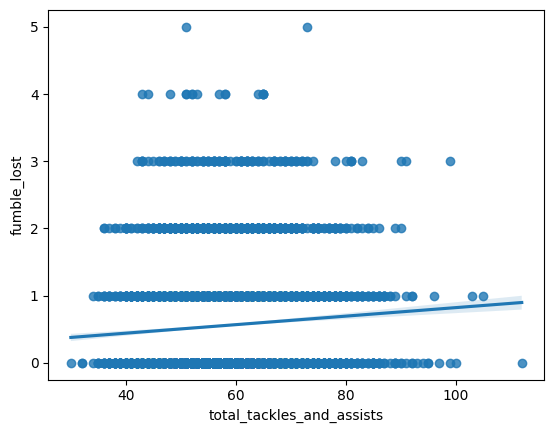

In [30]:
# let's see what correlates with Total tackles and assists

sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists', y='fumble_lost')

<Axes: xlabel='total_tackles_and_assists', ylabel='qb_hit'>

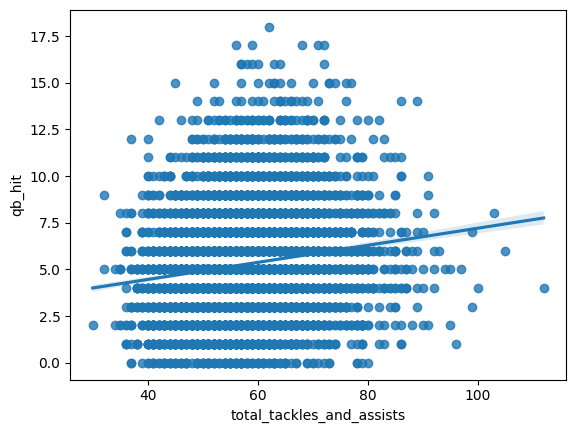

In [31]:
sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists', y='qb_hit')

<Axes: xlabel='def_touchdown', ylabel='total_tackles_and_assists'>

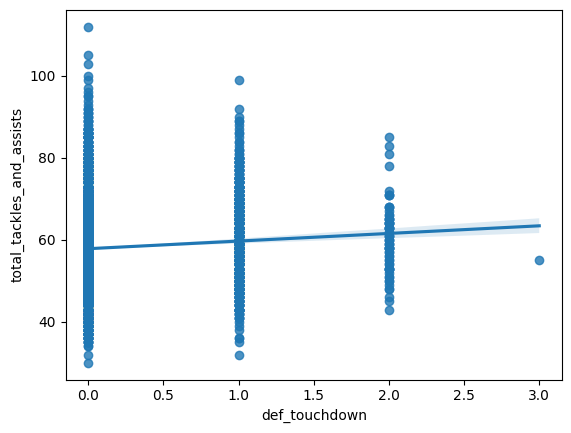

In [33]:
sns.regplot(data=weekly_df_defense, x = 'def_touchdown' , y='total_tackles_and_assists')

<Axes: xlabel='sack', ylabel='total_tackles_and_assists'>

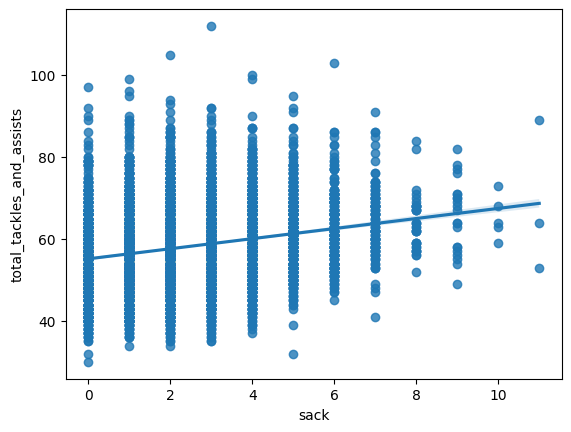

In [34]:
sns.regplot(data=weekly_df_defense, x = 'sack' , y='total_tackles_and_assists')

<Axes: xlabel='defensive_two_point_attempt', ylabel='total_tackles_and_assists'>

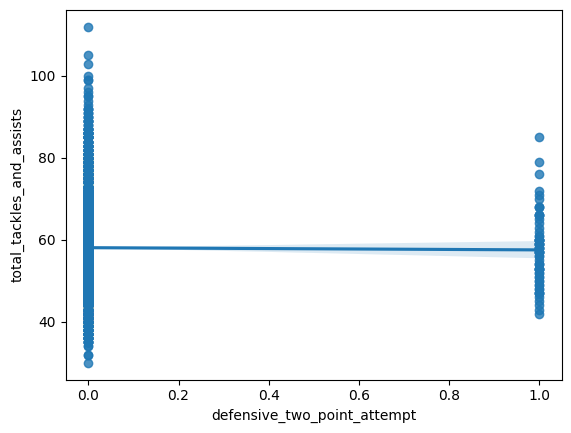

In [35]:
sns.regplot(data=weekly_df_defense, x = 'defensive_two_point_attempt' , y='total_tackles_and_assists')

<Axes: xlabel='total_off_points', ylabel='total_tackles_and_assists'>

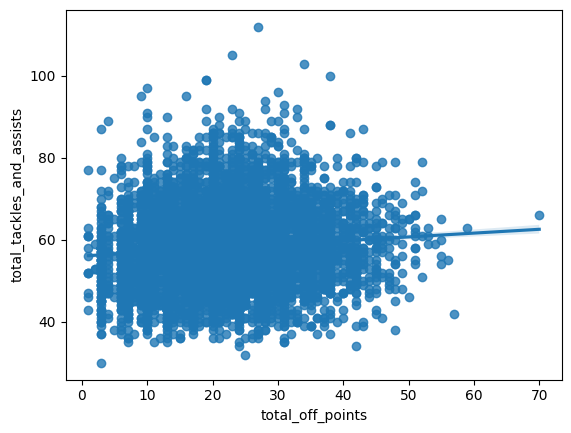

In [36]:
sns.regplot(data=weekly_df_defense, x = 'total_off_points' , y='total_tackles_and_assists')

<Axes: xlabel='total_def_points', ylabel='total_tackles_and_assists'>

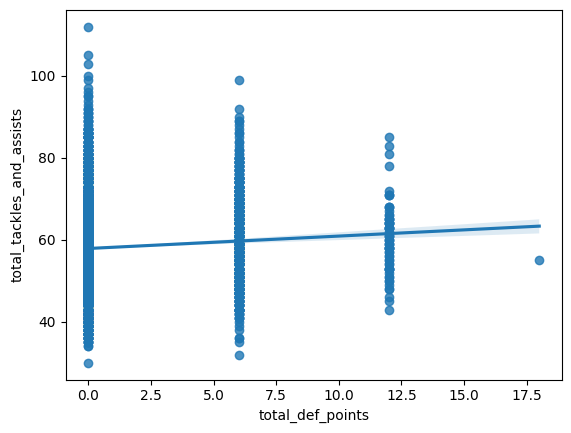

In [37]:
sns.regplot(data=weekly_df_defense, x = 'total_def_points' , y='total_tackles_and_assists')

<Axes: xlabel='extra_point', ylabel='total_tackles_and_assists'>

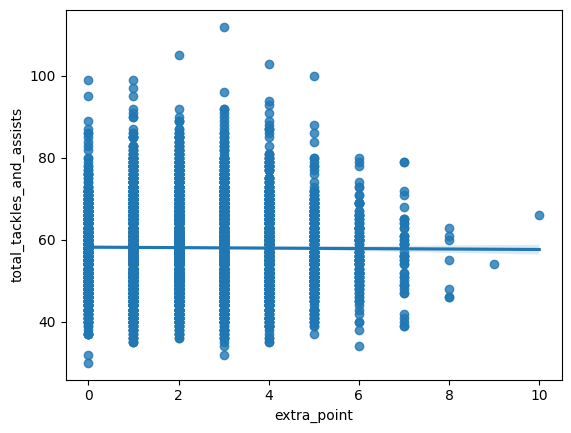

In [38]:
sns.regplot(data=weekly_df_defense, x = 'extra_point' , y='total_tackles_and_assists')

<Axes: xlabel='field_goal', ylabel='total_tackles_and_assists'>

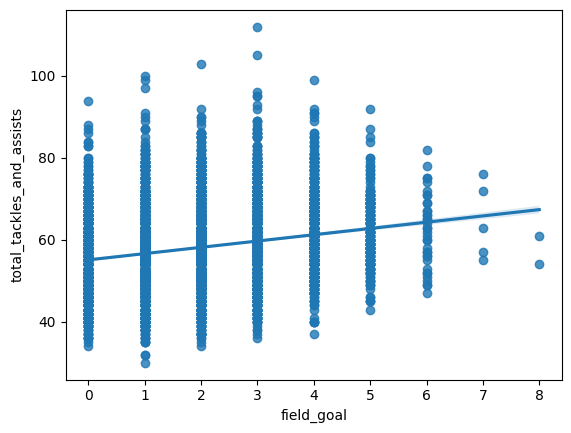

In [39]:
sns.regplot(data=weekly_df_defense, x = 'field_goal' , y='total_tackles_and_assists')

<Axes: xlabel='kickoff', ylabel='total_tackles_and_assists'>

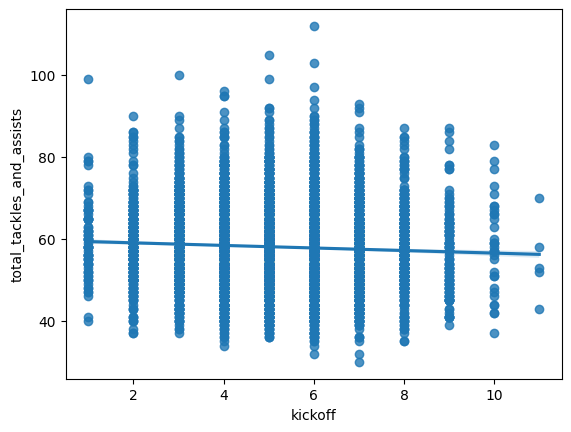

In [40]:
sns.regplot(data=weekly_df_defense, x = 'kickoff' , y='total_tackles_and_assists')

<Axes: xlabel='pass_snaps', ylabel='total_tackles_and_assists'>

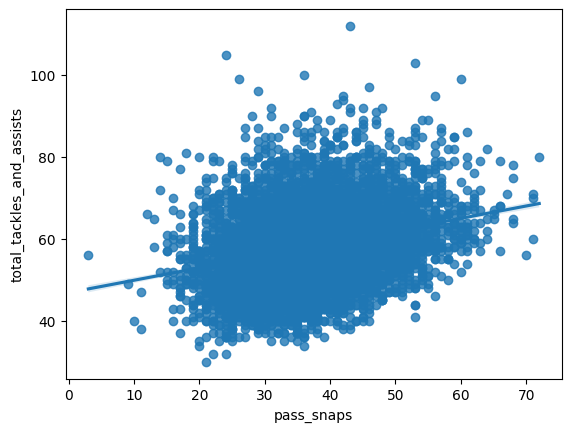

In [41]:
sns.regplot(data=weekly_df_defense, x = 'pass_snaps' , y='total_tackles_and_assists')

<Axes: xlabel='punt', ylabel='total_tackles_and_assists'>

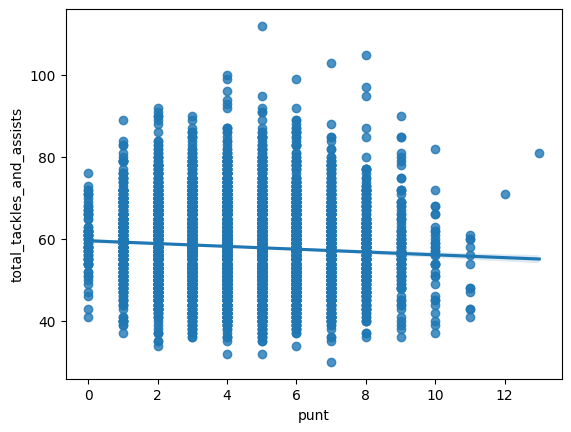

In [42]:
sns.regplot(data=weekly_df_defense, x = 'punt' , y='total_tackles_and_assists')

<Axes: xlabel='qb_kneel', ylabel='total_tackles_and_assists'>

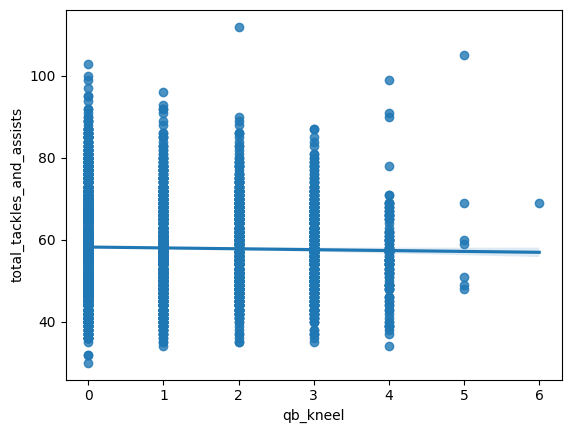

In [43]:
sns.regplot(data=weekly_df_defense, x = 'qb_kneel' , y='total_tackles_and_assists')

<Axes: xlabel='qb_spike', ylabel='total_tackles_and_assists'>

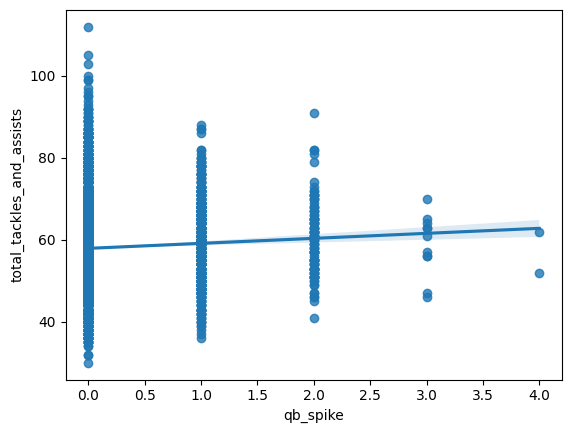

In [44]:
sns.regplot(data=weekly_df_defense, x = 'qb_spike' , y='total_tackles_and_assists')

<Axes: xlabel='rush_snaps', ylabel='total_tackles_and_assists'>

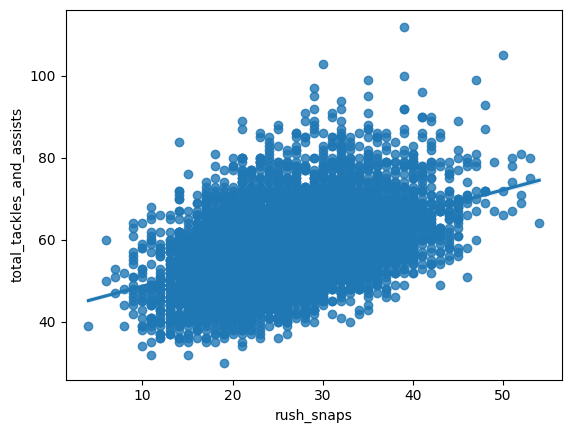

In [45]:
sns.regplot(data=weekly_df_defense, x = 'rush_snaps' , y='total_tackles_and_assists')

<Axes: xlabel='defense_snaps', ylabel='total_tackles_and_assists'>

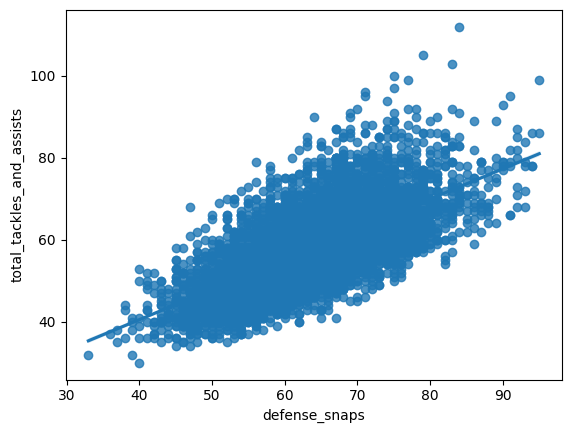

In [52]:
sns.regplot(data=weekly_df_defense, x = 'defense_snaps' , y='total_tackles_and_assists')

<Axes: xlabel='st_snaps', ylabel='total_tackles_and_assists'>

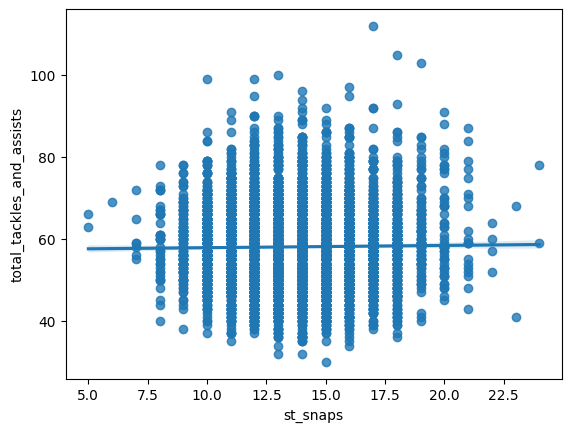

In [53]:
sns.regplot(data=weekly_df_defense, x = 'st_snaps' , y='total_tackles_and_assists')

<Axes: xlabel='total_tackles_and_assists', ylabel='rush_pct'>

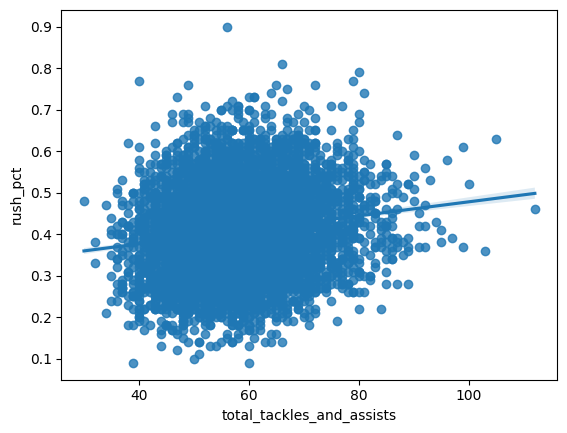

In [57]:
sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists' , y= 'rush_pct')

<Axes: xlabel='total_tackles_and_assists', ylabel='pass_pct'>

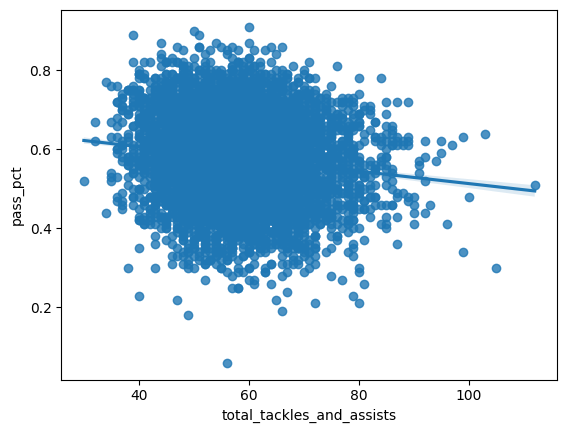

In [56]:
sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists' , y= 'pass_pct')

<Axes: xlabel='total_tackles_and_assists', ylabel='home_win'>

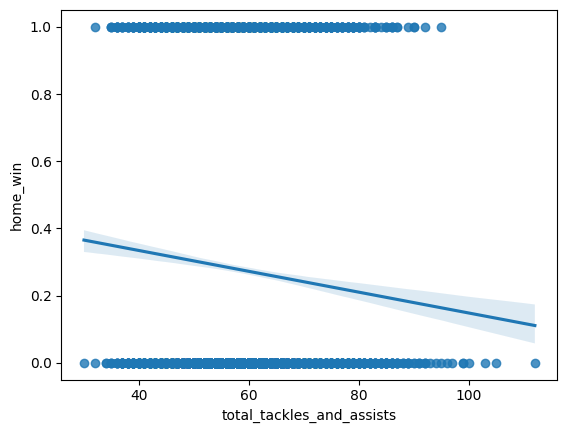

In [58]:
sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists' , y= 'home_win')

<Axes: xlabel='total_tackles_and_assists', ylabel='average_safety'>

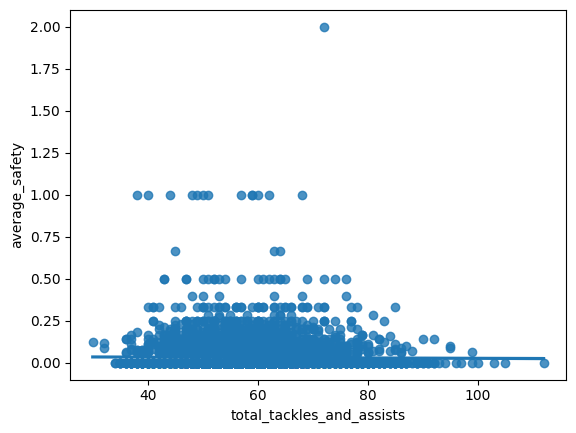

In [59]:
sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists' , y= 'average_safety')

<Axes: xlabel='total_tackles_and_assists', ylabel='average_interception'>

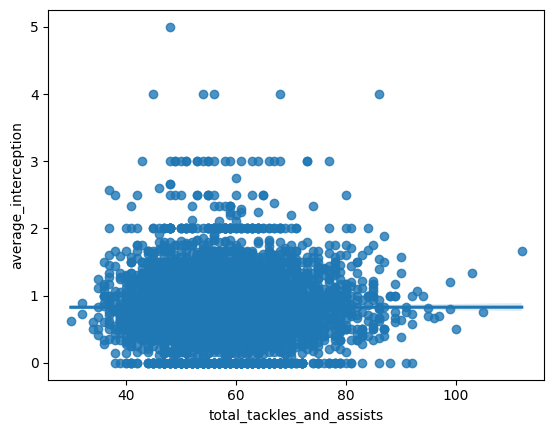

In [60]:
sns.regplot(data=weekly_df_defense, x = 'total_tackles_and_assists' , y= 'average_interception')

In [113]:
wdf_def_2024 = weekly_df_defense[
    (weekly_df_defense['season'].isin([2024]) &
     weekly_df_defense['game_id'].isin(['2024_01_ARI_BUF', '2024_03_DET_ARI']))][
         ['game_id','team','week','average_assist_tackle', 'total_tackles_and_assists','pass_pct', 'rush_pct', 'punt', 'home_win', 'home_loss', 'win', 'loss']]  # Using .copy() to avoid SettingWithCopyWarning
wdf_def_2024.head()

,game_id,team,week,average_assist_tackle,total_tackles_and_assists,pass_pct,rush_pct,punt,home_win,home_loss,win,loss
6518,2024_01_ARI_BUF,ARI,1,22.000000,66,0.43,0.55,2,0,0,0,1
6520,2024_03_DET_ARI,ARI,3,20.666667,68,0.37,0.60,5,0,1,1,2
6571,2024_01_ARI_BUF,BUF,1,11.000000,61,0.57,0.41,2,1,0,1,0
6696,2024_03_DET_ARI,DET,3,13.666667,46,0.66,0.34,5,0,0,2,1


In [114]:
 #Create a new column 'home_away_status'
wdf_def_2024['home_away_status'] = (
    # If home_win OR home_loss is 1, mark as "Home", else "Away"
    np.where(
        (wdf_def_2024['home_win'] == 1) | (wdf_def_2024['home_loss'] == 1),
        "Home",
        "Away"
    )
)

wdf_def_2024['team_home_away'] = (
    wdf_def_2024['team'] + '_' + wdf_def_2024['home_away_status'].str.lower()
)

wdf_def_2024.head()

,game_id,team,week,average_assist_tackle,total_tackles_and_assists,pass_pct,rush_pct,punt,home_win,home_loss,win,loss,home_away_status,team_home_away
6518,2024_01_ARI_BUF,ARI,1,22.000000,66,0.43,0.55,2,0,0,0,1,Away,ARI_away
6520,2024_03_DET_ARI,ARI,3,20.666667,68,0.37,0.60,5,0,1,1,2,Home,ARI_home
6571,2024_01_ARI_BUF,BUF,1,11.000000,61,0.57,0.41,2,1,0,1,0,Home,BUF_home
6696,2024_03_DET_ARI,DET,3,13.666667,46,0.66,0.34,5,0,0,2,1,Away,DET_away


In [115]:
# Pivot to get home/away teams per game
pivoted_teams = wdf_def_2024.pivot(
    index='game_id',
    columns='home_away_status',  # Splits into Home/Away columns
    values='team'               # Fill with team names
).rename(columns={
    'Home': 'team_home',
    'Away': 'team_away'
}).reset_index()

pivoted_metrics = weekly_df_defense.pivot(
    index='game_id',
    columns='home_away_status',
    values=['average_assist_tackle', 'total_tackles_and_assists']
)

# Flatten column names
pivoted_metrics.columns = [
    f'{metric}_{status.lower()}'
    for metric, status in pivoted_metrics.columns
]

# Merge with team names
final_df = pivoted_teams.merge(pivoted_metrics.reset_index(), on='game_id')

# Result:
final_df.head()

,game_id,team_away,team_home,average_assist_tackle_away,average_assist_tackle_home,total_tackles_and_assists_away,total_tackles_and_assists_home
0,2024_01_ARI_BUF,ARI,BUF,22.000000,11.000000,66.0,61.0
1,2024_03_DET_ARI,DET,ARI,13.666667,20.666667,46.0,68.0


In [107]:
defensive_df = wdf_def_2024.pivot_table(
    values=['total_tackles_and_assists', 'pass_pct'],
    index='game_id',
    columns='home_away_status',
    aggfunc='sum',
    fill_value=0
)
# Step 2: Flatten the MultiIndex columns for readability
defensive_df.columns = [
    f"{metric}_{status.lower()}"  # e.g., "average_assist_tackle_home"
    for metric, status in defensive_df.columns
]

# Step 3: Reset index to make game_id a column again
defensive_df = defensive_df.reset_index()

# Optional: Merge back other non-pivoted columns (e.g., week)
defensive_df = defensive_df.merge(
    weekly_df_defense[['game_id', 'week']].drop_duplicates(),
    on='game_id',
    how='left'
)

# Display the result

defensive_df.head()

,game_id,pass_pct_away,pass_pct_home,total_tackles_and_assists_away,total_tackles_and_assists_home,week
0,2024_01_ARI_BUF,0.43,0.57,66,61,1


In [302]:
num_columns_of = weekly_df_offense.shape[1]
num_rows_of = weekly_df_offense.shape[0]
column_names_of = weekly_df_offense.columns.tolist()

print(f"The dataset has {num_columns_of} columns and {num_rows_of} rows")

for col in column_names_of:
    null_count = weekly_df_offense[col].isnull().sum()  # Count null values
    print(f"Column: {col}, "
          f"Type: {weekly_df_offense[col].dtype}, "
          f"Unique Values: {weekly_df_offense[col].nunique()}, "
          f"Null Values: {null_count} ({null_count/num_rows_of:.1%})")

The dataset has 115 columns and 7088 rows
Column: game_id, Type: object, Unique Values: 3544, Null Values: 0 (0.0%)
Column: season, Type: int64, Unique Values: 13, Null Values: 0 (0.0%)
Column: week, Type: int64, Unique Values: 22, Null Values: 0 (0.0%)
Column: team, Type: object, Unique Values: 32, Null Values: 0 (0.0%)
Column: season_type, Type: object, Unique Values: 2, Null Values: 0 (0.0%)
Column: shotgun, Type: int64, Unique Values: 87, Null Values: 0 (0.0%)
Column: no_huddle, Type: int64, Unique Values: 70, Null Values: 0 (0.0%)
Column: qb_dropback, Type: int64, Unique Values: 63, Null Values: 0 (0.0%)
Column: qb_scramble, Type: int64, Unique Values: 12, Null Values: 0 (0.0%)
Column: total_off_yards, Type: int64, Unique Values: 461, Null Values: 0 (0.0%)
Column: pass_attempts, Type: int64, Unique Values: 62, Null Values: 0 (0.0%)
Column: complete_pass, Type: int64, Unique Values: 45, Null Values: 0 (0.0%)
Column: incomplete_pass, Type: int64, Unique Values: 32, Null Values: 0 (0

In [11]:
weekly_df_defense.head()

,game_id,season,week,team,season_type,safety,interception,fumble,fumble_lost,fumble_forced,...,average_solo_tackle,average_assist_tackle,average_tackle_with_assist,average_sack,average_qb_hit,average_def_touchdown,average_defensive_two_point_attempt,average_defensive_two_point_conv,average_defensive_extra_point_attempt,average_defensive_extra_point_conv
0,2012_01_SEA_ARI,2012,1,ARI,REG,0,1,2,1,1,...,55.000000,6.0,4.000000,3.0,8.000000,0.000000,0.0,0.0,0,0
1,2012_02_ARI_NE,2012,2,ARI,REG,0,1,0,0,0,...,51.000000,7.0,2.000000,3.5,7.000000,0.000000,0.0,0.0,0,0
2,2012_03_PHI_ARI,2012,3,ARI,REG,0,0,2,2,2,...,49.333333,6.0,1.666667,4.0,9.333333,0.333333,0.0,0.0,0,0
3,2012_04_MIA_ARI,2012,4,ARI,REG,0,2,4,2,3,...,50.500000,6.5,2.500000,4.0,9.500000,0.250000,0.0,0.0,0,0
4,2012_05_ARI_STL,2012,5,ARI,REG,0,1,0,0,0,...,47.400000,6.2,2.000000,3.4,8.800000,0.200000,0.0,0.0,0,0


In [12]:
weekly_df_offense.head()

,game_id,season,week,team,season_type,shotgun,no_huddle,qb_dropback,qb_scramble,total_off_yards,...,average_fourth_down_failed,average_rush_touchdown,average_pass_touchdown,average_safety,average_interception,average_fumble,average_fumble_lost,average_fumble_forced,average_fumble_not_forced,average_fumble_out_of_bounds
0,2012_01_SEA_ARI,2012,1,ARI,REG,31,0,38,1,258,...,0.000000,1.000000,1.000000,0.0,1.000000,2.000000,1.000000,2.000000,0.0,0.0
1,2012_02_ARI_NE,2012,2,ARI,REG,25,7,30,1,242,...,0.000000,1.000000,1.000000,0.0,0.500000,2.000000,1.500000,2.000000,0.0,0.0
2,2012_03_PHI_ARI,2012,3,ARI,REG,31,0,29,2,321,...,0.333333,0.666667,1.333333,0.0,0.333333,1.666667,1.333333,1.666667,0.0,0.0
3,2012_04_MIA_ARI,2012,4,ARI,REG,52,5,56,0,352,...,0.250000,0.500000,1.750000,0.0,0.750000,1.500000,1.000000,1.500000,0.0,0.0
4,2012_05_ARI_STL,2012,5,ARI,REG,56,7,59,1,334,...,0.600000,0.400000,1.400000,0.0,0.600000,1.400000,1.000000,1.400000,0.0,0.0


In [13]:
wdf_def_2024 = weekly_df_defense[
    (weekly_df_defense['season'].isin([2024])) ]  # Using .copy() to avoid SettingWithCopyWarning
wdf_def_2024.head()

,game_id,season,week,team,season_type,safety,interception,fumble,fumble_lost,fumble_forced,...,average_solo_tackle,average_assist_tackle,average_tackle_with_assist,average_sack,average_qb_hit,average_def_touchdown,average_defensive_two_point_attempt,average_defensive_two_point_conv,average_defensive_extra_point_attempt,average_defensive_extra_point_conv
6518,2024_01_ARI_BUF,2024,1,ARI,REG,0,0,1,1,1,...,28.000000,22.000000,14.000000,2.00,3.000000,0.0,0.0,0.0,0,0
6519,2024_02_LA_ARI,2024,2,ARI,REG,0,0,1,1,1,...,29.000000,18.500000,10.000000,3.50,6.000000,0.0,0.0,0.0,0,0
6520,2024_03_DET_ARI,2024,3,ARI,REG,0,1,0,0,0,...,30.333333,20.666667,9.333333,3.00,4.666667,0.0,0.0,0.0,0,0
6521,2024_04_WAS_ARI,2024,4,ARI,REG,0,1,0,0,0,...,33.500000,19.250000,8.250000,2.25,3.750000,0.0,0.0,0.0,0,0
6522,2024_05_ARI_SF,2024,5,ARI,REG,0,2,1,1,1,...,34.000000,18.000000,7.200000,2.20,4.000000,0.0,0.0,0.0,0,0


In [14]:
wdf_of_2024 = weekly_df_offense[
    (weekly_df_offense['season'].isin([2024])) ]
wdf_of_2024.head()

,game_id,season,week,team,season_type,shotgun,no_huddle,qb_dropback,qb_scramble,total_off_yards,...,average_fourth_down_failed,average_rush_touchdown,average_pass_touchdown,average_safety,average_interception,average_fumble,average_fumble_lost,average_fumble_forced,average_fumble_not_forced,average_fumble_out_of_bounds
6518,2024_01_ARI_BUF,2024,1,ARI,REG,51,4,38,3,286,...,1.0,2.000000,1.000000,0.0,0.000000,1.0,1.000000,1.000000,0.000000,0.0
6519,2024_02_LA_ARI,2024,2,ARI,REG,37,3,26,4,497,...,0.5,2.000000,2.000000,0.0,0.000000,1.5,1.000000,1.000000,0.500000,0.0
6520,2024_03_DET_ARI,2024,3,ARI,REG,47,8,37,2,284,...,1.0,1.333333,1.666667,0.0,0.333333,1.0,0.666667,0.666667,0.333333,0.0
6521,2024_04_WAS_ARI,2024,4,ARI,REG,43,13,27,1,323,...,1.0,1.250000,1.500000,0.0,0.250000,1.5,0.750000,1.250000,0.250000,0.0
6522,2024_05_ARI_SF,2024,5,ARI,REG,42,0,33,2,364,...,0.8,1.400000,1.400000,0.0,0.400000,1.4,0.600000,1.200000,0.200000,0.2


In [15]:
wdf_def_24_filtered = wdf_def_2024[['game_id', 'season', 'team', 'solo_tackle',
                                    'assist_tackle', 'tackle_with_assist', 'sack',
                                    'home_win', 'home_loss', 'qb_hit', 'interception',
                                    'fumble_forced', 'def_touchdown', 'safety', 'defense_snaps'
                                    ]]
wdf_def_24_filtered.head()

,game_id,season,team,solo_tackle,assist_tackle,tackle_with_assist,sack,home_win,home_loss,qb_hit,interception,fumble_forced,def_touchdown,safety,defense_snaps
6518,2024_01_ARI_BUF,2024,ARI,28,22,14,2,0,0,3,0,1,0,0,58
6519,2024_02_LA_ARI,2024,ARI,30,15,6,5,1,0,9,0,1,0,0,52
6520,2024_03_DET_ARI,2024,ARI,33,25,8,2,0,1,2,1,0,0,0,68
6521,2024_04_WAS_ARI,2024,ARI,43,15,5,0,0,1,1,1,0,0,0,68
6522,2024_05_ARI_SF,2024,ARI,36,13,3,2,0,0,5,2,1,0,0,63


In [16]:
wdf_def_24_filtered['total_tackles_and_assists'] = (wdf_def_24_filtered['solo_tackle'] + wdf_def_24_filtered['assist_tackle'] + wdf_def_24_filtered['tackle_with_assist'] + wdf_def_24_filtered['sack'])



In [17]:

defensive_df = wdf_def_24_filtered.pivot_table(
    values=['total_tackles_and_assists', 'sack', 'qb_hit', 'interception', 'fumble_forced', 'def_touchdown', 'safety'],
    index='game_id',
    # columns='team',
    aggfunc='sum',
    fill_value=0
)

defensive_df.head()

,def_touchdown,fumble_forced,interception,qb_hit,sack,safety,total_tackles_and_assists
game_id,,,,,,,
2024_01_ARI_BUF,0,2,0,8,6,0,127
2024_01_BAL_KC,0,1,1,7,3,0,109
2024_01_CAR_NO,0,1,2,6,5,0,115
2024_01_DAL_CLE,0,2,2,21,9,0,135
2024_01_DEN_SEA,0,2,3,15,4,2,135


In [310]:
defensive_df = wdf_def_24_filtered.pivot_table(
    values=['total_tackles_and_assists', 'sack', 'qb_hit', 'interception', 'fumble_forced', 'def_touchdown', 'safety'],
    index='game_id',
    # columns='team',
    aggfunc='sum',
    fill_value=0
)

defensive_df.head()

,def_touchdown,fumble_forced,interception,qb_hit,sack,safety,total_tackles_and_assists
game_id,,,,,,,
2024_01_ARI_BUF,0,2,0,8,6,0,127
2024_01_BAL_KC,0,1,1,7,3,0,109
2024_01_CAR_NO,0,1,2,6,5,0,115
2024_01_DAL_CLE,0,2,2,21,9,0,135
2024_01_DEN_SEA,0,2,3,15,4,2,135


In [311]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def create_defensive_index(df):
    """
    Create comprehensive defensive index for NFL teams

    Parameters:
    df (DataFrame): DataFrame with defensive statistics

    Returns:
    DataFrame: Original DataFrame with defensive index added
    """

    # Define component metrics and weights
    component_metrics = {
        'tackles': {
            'weight': 0.35,
            'metrics': ['solo_tackle', 'assist_tackle', 'tackle_with_assist']
        },
        'pass_rush': {
            'weight': 0.25,
            'metrics': ['sack', 'qb_hit']
        },
        'turnovers': {
            'weight': 0.20,
            'metrics': ['interception', 'fumble_forced']
        },
        'defensive_scoring': {
            'weight': 0.10,
            'metrics': ['def_touchdown', 'safety']
        },
        'volume_opportunity': {
            'weight': 0.10,
            'metrics': ['defense_snaps']
        }
    }

    df_result = df.copy()
    scaler = StandardScaler()

    # Step 1: Normalize all metrics using z-scores
    all_metrics = []
    for component in component_metrics.values():
        all_metrics.extend(component['metrics'])

    available_metrics = [metric for metric in all_metrics if metric in df.columns]

    # Calculate z-scores
    for metric in available_metrics:
        df_result[f'{metric}_zscore'] = scaler.fit_transform(df[[metric]]).flatten()

    # Step 2: Calculate component scores
    component_scores = {}
    for component_name, component_info in component_metrics.items():
        available_component_metrics = [metric for metric in component_info['metrics']
                                     if metric in df.columns]

        if available_component_metrics:
            zscore_columns = [f'{metric}_zscore' for metric in available_component_metrics]
            component_scores[component_name] = df_result[zscore_columns].mean(axis=1)
        else:
            component_scores[component_name] = pd.Series(0, index=df.index)

    # Step 3: Calculate weighted composite index
    defensive_index_raw = 0
    for component_name, component_score in component_scores.items():
        weight = component_metrics[component_name]['weight']
        defensive_index_raw += weight * component_score

    # Step 4: Scale to 0-100 range
    min_score = defensive_index_raw.min()
    max_score = defensive_index_raw.max()

    if max_score != min_score:
        defensive_index_scaled = 100 * (defensive_index_raw - min_score) / (max_score - min_score)
    else:
        defensive_index_scaled = pd.Series(50, index=df.index)

    # Add results to dataframe
    df_result['defensive_index'] = defensive_index_scaled

    # Add component scores for analysis
    for component_name, component_score in component_scores.items():
        df_result[f'defensive_{component_name}_component'] = component_score

    return df_result

# Usage example
df_with_defensive_index = create_defensive_index(defensive_df)

df_with_defensive_index.head()


,def_touchdown,fumble_forced,interception,qb_hit,sack,safety,total_tackles_and_assists,sack_zscore,qb_hit_zscore,interception_zscore,fumble_forced_zscore,def_touchdown_zscore,safety_zscore,defensive_index,defensive_tackles_component,defensive_pass_rush_component,defensive_turnovers_component,defensive_defensive_scoring_component,defensive_volume_opportunity_component
game_id,,,,,,,,,,,,,,,,,,,
2024_01_ARI_BUF,0,2,0,8,6,0,127,0.458862,-0.626172,-1.129058,0.350740,-0.416452,-0.237443,39.695370,0,-0.083655,-0.389159,-0.326948,0
2024_01_BAL_KC,0,1,1,7,3,0,109,-0.774870,-0.872662,-0.334536,-0.496387,-0.416452,-0.237443,27.129214,0,-0.823766,-0.415461,-0.326948,0
2024_01_CAR_NO,0,1,2,6,5,0,115,0.047618,-1.119152,0.459987,-0.496387,-0.416452,-0.237443,37.130723,0,-0.535767,-0.018200,-0.326948,0
2024_01_DAL_CLE,0,2,2,21,9,0,135,1.692593,2.578201,0.459987,0.350740,-0.416452,-0.237443,86.824195,0,2.135397,0.405364,-0.326948,0
2024_01_DEN_SEA,0,2,3,15,4,2,135,-0.363626,1.099260,1.254509,0.350740,-0.416452,7.723886,89.176691,0,0.367817,0.802625,3.653717,0


In [312]:
wdf_of_2024.head()

,game_id,season,week,team,season_type,shotgun,no_huddle,qb_dropback,qb_scramble,total_off_yards,...,average_fourth_down_failed,average_rush_touchdown,average_pass_touchdown,average_safety,average_interception,average_fumble,average_fumble_lost,average_fumble_forced,average_fumble_not_forced,average_fumble_out_of_bounds
6518,2024_01_ARI_BUF,2024,1,ARI,REG,51,4,38,3,286,...,1.0,2.000000,1.000000,0.0,0.000000,1.0,1.000000,1.000000,0.000000,0.0
6519,2024_02_LA_ARI,2024,2,ARI,REG,37,3,26,4,497,...,0.5,2.000000,2.000000,0.0,0.000000,1.5,1.000000,1.000000,0.500000,0.0
6520,2024_03_DET_ARI,2024,3,ARI,REG,47,8,37,2,284,...,1.0,1.333333,1.666667,0.0,0.333333,1.0,0.666667,0.666667,0.333333,0.0
6521,2024_04_WAS_ARI,2024,4,ARI,REG,43,13,27,1,323,...,1.0,1.250000,1.500000,0.0,0.250000,1.5,0.750000,1.250000,0.250000,0.0
6522,2024_05_ARI_SF,2024,5,ARI,REG,42,0,33,2,364,...,0.8,1.400000,1.400000,0.0,0.400000,1.4,0.600000,1.200000,0.200000,0.2


In [313]:
offensive_df = wdf_of_2024.pivot_table(
    values=['total_yards', 'total_tds', 'receiving_touchdown', 'passing_air_yards', 'comp_pct', 'ypa', 'ypc', 'pass_td_pct', 'rec_td_pct', 'rush_td_pct', 'td_pct',
            'touches', 'targets', 'rush_attempts', 'pass_attempts','yptarget', 'ayptarget', 'ypr', 'adot', 'receiving_air_yards', 'passing_air_yards',
            'receiving_touchdown', 'average_pass_touchdown', 'average_rush_touchdown', 'total_tds'],
    index='game_id',
    # columns='team',
    aggfunc='sum',
    fill_value=0
)

offensive_df.head()

,adot,average_pass_touchdown,average_rush_touchdown,ayptarget,comp_pct,pass_attempts,pass_td_pct,passing_air_yards,passing_air_yards,rec_td_pct,...,targets,td_pct,total_tds,total_tds,total_yards,touches,ypa,ypc,ypr,yptarget
game_id,,,,,,,,,,,,,,,,,,,,,
2024_01_ARI_BUF,13.378,3.0,4.0,13.38,1.460,54,0.119,357,357,0.119,...,54,0.13,10,10,1042,152,15.32,8.71,20.60,15.32
2024_01_BAL_KC,12.623,2.0,3.0,12.62,1.375,68,0.061,432,432,0.061,...,68,0.09,7,7,1385,166,17.44,9.38,25.05,17.44
2024_01_CAR_NO,21.874,3.0,3.0,21.88,1.240,53,0.125,591,591,0.125,...,53,0.12,9,9,960,142,13.88,7.76,22.91,13.88
2024_01_DAL_CLE,18.248,2.0,3.0,18.25,1.152,75,0.054,685,685,0.054,...,75,0.09,7,7,891,162,9.52,8.97,16.46,9.52
2024_01_DEN_SEA,13.558,1.0,3.0,13.56,1.400,64,0.042,431,431,0.042,...,64,0.06,5,5,863,166,10.57,8.38,14.81,10.57


In [316]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def create_offensive_index(df):
    # Define components and their variables and weights
    component_dict = {
        'production': {
            'weight': 0.30,
            'vars': ['total_yards', 'total_tds', 'receiving_touchdown', 'passing_air_yards']
        },
        'efficiency': {
            'weight': 0.25,
            'vars': ['comp_pct', 'ypa', 'ypc', 'pass_td_pct', 'rec_td_pct', 'rush_td_pct', 'td_pct']
        },
        'volume': {
            'weight': 0.20,
            'vars': ['touches', 'targets', 'rush_attempts', 'pass_attempts']
        },
        'big_play': {
            'weight': 0.15,
            'vars': ['yptarget', 'ayptarget', 'ypr', 'adot', 'receiving_air_yards', 'passing_air_yards']
        },
        'red_zone': {
            'weight': 0.10,
            'vars': ['receiving_touchdown', 'average_pass_touchdown', 'average_rush_touchdown', 'total_tds']
        }
    }

    df_result = df.copy()
    scaler = StandardScaler()
    all_vars = [var for comp in component_dict.values() for var in comp['vars']]
    # Use only variables that exist in the DataFrame
    used_vars = [v for v in all_vars if v in df.columns]

    # 1. Normalize inputs
    for var in used_vars:
        df_result[f'{var}_zscore'] = scaler.fit_transform(df[[var]]).flatten()

    # 2. Component subindices (mean of normalized metrics per component)
    comp_scores = {}
    for cname, cinfo in component_dict.items():
        # Only use available variables
        c_vars = [v for v in cinfo['vars'] if v in df.columns]
        z_cols = [f'{v}_zscore' for v in c_vars]
        comp_scores[cname] = df_result[z_cols].mean(axis=1) if z_cols else pd.Series(0, index=df.index)
        df_result[f'off_{cname}_component'] = comp_scores[cname]

    # 3. Weighted composite index (sum product of components)
    offensive_index_raw = sum(comp_scores[cname] * cinfo['weight'] for cname, cinfo in component_dict.items())

    # 4. Scale to 0-100
    minval, maxval = offensive_index_raw.min(), offensive_index_raw.max()
    if maxval != minval:
        offensive_index_scaled = 100 * (offensive_index_raw - minval) / (maxval - minval)
    else:
        offensive_index_scaled = pd.Series(50, index=df.index)

    df_result['offensive_index'] = offensive_index_scaled

    return df_result

# Example usage:
offensive_df = create_offensive_index(offensive_df)
# print(offensive_df[['team', 'week', 'offensive_index'] + [col for col in offensive_df.columns if col.startswith('off_')]].head())




ValueError: Length of values (570) does not match length of index (285)

In [315]:
offensive_data = offensive_df[['offensive_index','off_production_component','off_efficiency_component','off_volume_component', 'off_big_play_component', 'off_red_zone_component' ]]
offensive_data.head()


KeyError: "None of [Index(['offensive_index', 'off_production_component',\n       'off_efficiency_component', 'off_volume_component',\n       'off_big_play_component', 'off_red_zone_component'],\n      dtype='object')] are in the [columns]"

In [ ]:
deffensive_data = df_with_defensive_index[['total_tackles_and_assists','defensive_index','defensive_tackles_component','defensive_pass_rush_component','defensive_turnovers_component','defensive_defensive_scoring_component','defensive_volume_opportunity_component']]


deffensive_data.head()


,total_tackles_and_assists,defensive_index,defensive_tackles_component,defensive_pass_rush_component,defensive_turnovers_component,defensive_defensive_scoring_component,defensive_volume_opportunity_component
game_id,,,,,,,
2024_01_ARI_BUF,127,39.695370,0,-0.083655,-0.389159,-0.326948,0
2024_01_BAL_KC,109,27.129214,0,-0.823766,-0.415461,-0.326948,0
2024_01_CAR_NO,115,37.130723,0,-0.535767,-0.018200,-0.326948,0
2024_01_DAL_CLE,135,86.824195,0,2.135397,0.405364,-0.326948,0
2024_01_DEN_SEA,135,89.176691,0,0.367817,0.802625,3.653717,0


In [317]:
merged_df = pd.merge(
    offensive_data,
    deffensive_data,
    on=['game_id'],
    suffixes=('_off', '_def')
)

merged_df.head()

,offensive_index,off_production_component,off_efficiency_component,off_volume_component,off_big_play_component,off_red_zone_component,total_tackles_and_assists,defensive_index,defensive_tackles_component,defensive_pass_rush_component,defensive_turnovers_component,defensive_defensive_scoring_component,defensive_volume_opportunity_component
game_id,,,,,,,,,,,,,
2024_01_ARI_BUF,42.527851,-0.298337,0.569209,-0.484898,-0.677070,0.988487,127,39.695370,0,-0.083655,-0.389159,-0.326948,0
2024_01_BAL_KC,44.484348,-0.089807,0.177423,0.228998,-0.220581,-0.090906,109,27.129214,0,-0.823766,-0.415461,-0.326948,0
2024_01_CAR_NO,45.166197,0.005587,0.080945,-0.792926,0.851268,0.536908,115,37.130723,0,-0.535767,-0.018200,-0.326948,0
2024_01_DAL_CLE,40.498583,-0.176211,-0.501136,0.220936,0.171384,-0.090906,135,86.824195,0,2.135397,0.405364,-0.326948,0
2024_01_DEN_SEA,26.252058,-1.014287,-0.529138,0.240976,-1.011393,-0.718720,135,89.176691,0,0.367817,0.802625,3.653717,0


In [318]:
from sklearn.preprocessing import StandardScaler

# Reshape to 2D as required by scikit-learn
y = merged_df['total_tackles_and_assists'].values.reshape(-1, 1)

scaler = StandardScaler()
y_normalized = scaler.fit_transform(y).flatten()

# Add normalized target as a new column (optional)
merged_df['total_tackles_and_assists_z'] = y_normalized

# To inverse transform predictions later:
# y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

merged_df.head()

,offensive_index,off_production_component,off_efficiency_component,off_volume_component,off_big_play_component,off_red_zone_component,total_tackles_and_assists,defensive_index,defensive_tackles_component,defensive_pass_rush_component,defensive_turnovers_component,defensive_defensive_scoring_component,defensive_volume_opportunity_component,total_tackles_and_assists_z
game_id,,,,,,,,,,,,,,
2024_01_ARI_BUF,42.527851,-0.298337,0.569209,-0.484898,-0.677070,0.988487,127,39.695370,0,-0.083655,-0.389159,-0.326948,0,1.425336
2024_01_BAL_KC,44.484348,-0.089807,0.177423,0.228998,-0.220581,-0.090906,109,27.129214,0,-0.823766,-0.415461,-0.326948,0,-0.755390
2024_01_CAR_NO,45.166197,0.005587,0.080945,-0.792926,0.851268,0.536908,115,37.130723,0,-0.535767,-0.018200,-0.326948,0,-0.028481
2024_01_DAL_CLE,40.498583,-0.176211,-0.501136,0.220936,0.171384,-0.090906,135,86.824195,0,2.135397,0.405364,-0.326948,0,2.394548
2024_01_DEN_SEA,26.252058,-1.014287,-0.529138,0.240976,-1.011393,-0.718720,135,89.176691,0,0.367817,0.802625,3.653717,0,2.394548


In [319]:
features = ['offensive_index', 'defensive_index', 'off_production_component',
            'off_efficiency_component', 'off_volume_component', 'off_big_play_component',
            'off_red_zone_component','defensive_tackles_component','defensive_pass_rush_component',
            'defensive_turnovers_component','defensive_defensive_scoring_component','defensive_volume_opportunity_component']  # Add more context features as needed
target = 'total_tackles_and_assists_z'
X = merged_df[features]
y = merged_df[target]


In [320]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [321]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)  # Fit the model


LinearRegression()

In [322]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.5f}")


MSE: 0.78
MAE: 0.72
R^2: 0.29227


In [323]:
coefs = pd.Series(model.coef_, index=features)
print(coefs)


offensive_index                           2.216703e-02
defensive_index                           1.934749e-02
off_production_component                 -8.839735e-01
off_efficiency_component                  5.454200e-01
off_volume_component                      7.294315e-01
off_big_play_component                    6.512689e-02
off_red_zone_component                   -2.604866e-01
defensive_tackles_component              -2.220446e-16
defensive_pass_rush_component             1.716180e-01
defensive_turnovers_component            -9.804080e-02
defensive_defensive_scoring_component    -2.300337e-01
defensive_volume_opportunity_component    0.000000e+00
dtype: float64


In [324]:
print(f"Intercept: {model.intercept_}")


Intercept: -1.9347706070872417


In [325]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Prepare features and target
features = ['offensive_index', 'defensive_index', 'off_production_component',
            'off_efficiency_component', 'off_volume_component', 'off_big_play_component',
            'off_red_zone_component','defensive_pass_rush_component',
            'defensive_turnovers_component','defensive_defensive_scoring_component']
target = 'total_tackles_and_assists_z'

X = merged_df[features]
y = merged_df[target]

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,  # Increased from 100
    max_depth=10,      # Limit tree depth to prevent overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 4. Predict on test data
y_pred = rf.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# 6. (Optional) Feature Importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

# 7. (Optional) If you want to inverse-transform your predictions to original scale (if you normalized target):
# from sklearn.preprocessing import StandardScaler
# y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()


Random Forest Performance on Test Set:
Mean Squared Error (MSE): 0.9376
Mean Absolute Error (MAE): 0.8181
R^2 Score: 0.1470

Feature Importances:
defensive_index                          0.201380
defensive_pass_rush_component            0.196622
off_volume_component                     0.195572
off_red_zone_component                   0.085237
off_efficiency_component                 0.082318
off_big_play_component                   0.081441
defensive_turnovers_component            0.053808
off_production_component                 0.046348
offensive_index                          0.044738
defensive_defensive_scoring_component    0.012536
dtype: float64


Feature Correlations with Target:
off_red_zone_component                  -0.057757
off_efficiency_component                -0.016642
defensive_defensive_scoring_component    0.021093
off_big_play_component                   0.046854
off_production_component                 0.070591
offensive_index                          0.081772
defensive_turnovers_component            0.183799
off_volume_component                     0.243614
defensive_pass_rush_component            0.371646
defensive_index                          0.372858
total_tackles_and_assists_z              1.000000
Name: total_tackles_and_assists_z, dtype: float64

Feature Correlation Matrix:
                                       defensive_index  off_volume_component  \
defensive_index                               1.000000             -0.034526   
off_volume_component                         -0.034526              1.000000   
defensive_pass_rush_component                 0.826086             -0.067276   
off_efficiency_co

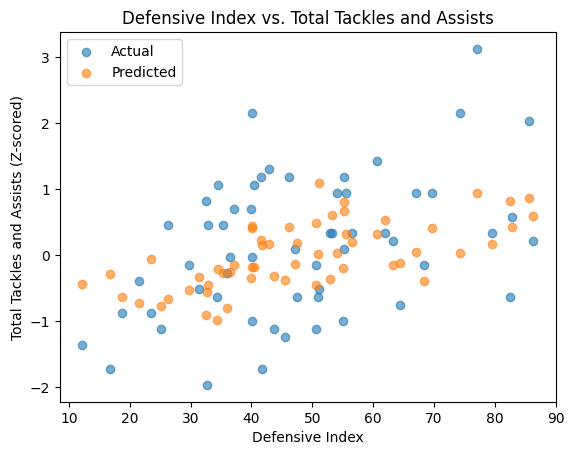

In [326]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# 1. Prepare features and target
features = [
    'defensive_index', 'off_volume_component', 'defensive_pass_rush_component',
    'off_efficiency_component', 'off_red_zone_component', 'off_big_play_component',
    'defensive_turnovers_component', 'offensive_index', 'off_production_component',
    'defensive_defensive_scoring_component']
    # Add raw stats if available
    #'solo_tackle', 'assist CALLBACK_FAILED
#System: It looks like the response was cut off due to an error ("CALLBACK_FAILED"). I'll complete the enhanced code you requested, incorporating the suggestions for improving the random forest model, and provide a final interpretation of the results with the added `offensive_index` and `defensive_index`. I'll also address any remaining questions and ensure the code is robust for your use case.

### Enhanced Code
#Below is the completed version of the enhanced random forest model code, including feature engineering, cross-validation, inverse transformation for interpretability, and visualization. This builds on your original code and adds recommendations from the previous response, tailored to predicting `total_tackles_and_assists_z` in `merged_df`.

#<xaiArtifact artifact_id="fa6433b3-248d-44dc-af6f-ccc41f6165a0" artifact_version_id="92abe700-903d-4101-b204-6a7ef16a1fe6" title="enhanced_rf_model.py" contentType="text/python">
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# 1. Prepare features and target
features = [
    'defensive_index', 'off_volume_component', 'defensive_pass_rush_component',
    'off_efficiency_component', 'off_red_zone_component', 'off_big_play_component',
    'defensive_turnovers_component', 'offensive_index', 'off_production_component',
    'defensive_defensive_scoring_component',
    # Add raw stats if available in merged_df
    'solo_tackle', 'assist_tackle', 'tackle_with_assist', 'defense_snaps',
    'rush_snaps_y', 'pass_snaps_y', 'rush_pct_y', 'pass_pct_y'
]
# Filter features that exist in merged_df
features = [f for f in features if f in merged_df.columns]
target = 'total_tackles_and_assists_z'

# 2. Check correlations to identify redundant or weak features
print("Feature Correlations with Target:")
print(merged_df[features + [target]].corr()[target].sort_values())
print("\nFeature Correlation Matrix:")
print(merged_df[features].corr())

# 3. Split into train/test
X = merged_df[features]
y = merged_df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train the Random Forest with tuned parameters
rf = RandomForestRegressor(
    n_estimators=200,  # Increased from 100
    max_depth=10,      # Limit tree depth to prevent overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 5. Cross-validation for robust performance estimate
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"\nCross-Validated R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# 6. Predict on test data
y_pred = rf.predict(X_test)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# 8. Inverse-transform to original tackle scale
scaler_y = StandardScaler().fit(merged_df[[target]])  # Replace with your actual scaler if different
y_test_original = scaler_y.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
print(f"MAE in Tackles: {mean_absolute_error(y_test_original, y_pred_original):.2f}")
print(f"Original Tackles Stats:")
print(f"Mean: {y_test_original.mean():.2f}, Std: {y_test_original.std():.2f}")

# 9. Feature Importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

# 10. Plot top feature vs. target
plt.scatter(X_test['defensive_index'], y_test, label='Actual', alpha=0.6)
plt.scatter(X_test['defensive_index'], y_pred, label='Predicted', alpha=0.6)
plt.xlabel('Defensive Index')
plt.ylabel('Total Tackles and Assists (Z-scored)')
plt.title('Defensive Index vs. Total Tackles and Assists')
plt.legend()
plt.show()

In [328]:

features = [
    'offensive_index', 'defensive_index', 'off_production_component',
    'off_efficiency_component', 'off_volume_component', 'off_big_play_component',
    'off_red_zone_component', 'defensive_tackles_component', 'defensive_pass_rush_component',
    'defensive_turnovers_component', 'defensive_defensive_scoring_component', 'defensive_volume_opportunity_component'
]
target = 'total_tackles_and_assists_z'  # example: normalized target

X = merged_df[features]
y = merged_df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,      # number of trees
    learning_rate=0.1,     # step size shrinkage
    max_depth=6,           # tree depth
    subsample=0.8,         # row sampling
    colsample_bytree=0.8,  # feature sampling
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f} | MAE: {mae:.4f} | R^2: {r2:.4f}")



MSE: 1.0243 | MAE: 0.8403 | R^2: 0.0681


In [329]:
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
print(importances)


defensive_pass_rush_component             0.218288
defensive_turnovers_component             0.122096
defensive_defensive_scoring_component     0.119911
off_volume_component                      0.117167
defensive_index                           0.080330
off_big_play_component                    0.079355
off_efficiency_component                  0.076868
off_production_component                  0.075296
off_red_zone_component                    0.071658
offensive_index                           0.039030
defensive_tackles_component               0.000000
defensive_volume_opportunity_component    0.000000
dtype: float32
